# Problems Notebook

This notebook contains solutions to the Winter 25/26 Computer Infrastructure Assessment.
All code is reproducible and documented with Markdown explanations.


In [1]:
# Setup cell: import all required libraries for the assessment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Optional: make plots display inline in the notebook
%matplotlib inline

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
# Problem 1: Download historical stock data using yfinance

# Step 1: Choose the stock symbol you want to analyze
# A ticker symbol is a unique series of letters assigned to a security for trading purposes.
# Here we use "AAPL" for Apple Inc.
ticker_symbol = "AAPL"

# Step 2: Download historical stock data using yfinance
# yf.download() fetches stock price data from Yahoo Finance.
# Parameters:
#   - ticker_symbol: the stock symbol to fetch
#   - period="1y": fetch data for the last 1 year
#   - interval="1d": get daily stock prices
#   - auto_adjust=False: download raw prices without adjusting for stock splits or dividends
# Note: If auto_adjust=True, Yahoo Finance automatically adjusts prices for splits/dividends,
# which can be useful for certain analyses but may hide the actual historical prices.
stock_data = yf.download(ticker_symbol, period="1y", interval="1d", auto_adjust=False)

# Step 3: Preview the first 5 rows of the data
# stock_data.head() shows the first 5 rows of the DataFrame
# Columns typically include: Open, High, Low, Close, Adj Close, and Volume
# This helps us confirm that the data was downloaded correctly
stock_data.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-12-13,247.012833,248.130005,249.289993,246.240005,247.820007,33155300
2024-12-16,249.909714,251.039993,251.380005,247.649994,247.990005,51694800
2024-12-17,252.338730,253.479996,253.830002,249.779999,250.080002,51356400
2024-12-18,246.933182,248.050003,254.279999,247.740005,252.160004,56774100
2024-12-19,248.665359,249.789993,252.000000,247.089996,247.500000,60882300


In [4]:
# ==============================
# Cell 3: Clean & Prepare the Data
# ==============================

# Step 4a: Check for missing values in each column
# .isnull() returns True for any missing value, .sum() counts them per column
print("Missing values per column:\n", stock_data.isnull().sum())

# Step 4b: Drop any rows with missing data
# This ensures calculations like moving averages or percentage changes do not fail
# Usually stock data from yfinance is complete, but this is good practice
stock_data = stock_data.dropna()

# Step 4c: Verify the data types of each column
# Ensures numeric operations like rolling averages and plotting will work correctly
print("\nData types:\n", stock_data.dtypes)


Missing values per column:
 Price      Ticker
Adj Close  AAPL      0
Close      AAPL      0
High       AAPL      0
Low        AAPL      0
Open       AAPL      0
Volume     AAPL      0
dtype: int64

Data types:
 Price      Ticker
Adj Close  AAPL      float64
Close      AAPL      float64
High       AAPL      float64
Low        AAPL      float64
Open       AAPL      float64
Volume     AAPL        int64
dtype: object


In [5]:
# ==============================
# Cell 4: Summary Statistics
# ==============================

# Step 5a: Generate descriptive statistics for all numeric columns
# .describe() calculates count, mean, standard deviation, min, quartiles, and max
# This provides a quick overview of stock performance and variability
stock_summary = stock_data.describe()

# Step 5b: Display the summary statistics table
# Columns include Open, High, Low, Close, Adj Close, Volume, and any additional calculated columns
stock_summary


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,250.000000,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,230.765125,231.280600,233.757960,228.621880,231.013580,5.455840e+07
std,25.415847,25.316789,25.041746,25.465161,25.285861,2.314669e+07
min,171.832428,172.419998,190.339996,169.210007,171.949997,2.013560e+07
25%,209.571266,210.050003,212.157505,207.825001,210.025002,4.119330e+07
50%,229.652374,230.004997,232.769997,227.644997,229.985001,4.804070e+07
75%,249.244026,250.262497,253.355003,247.420002,249.267502,5.861452e+07
max,286.190002,286.190002,288.619995,283.299988,286.200012,1.843959e+08


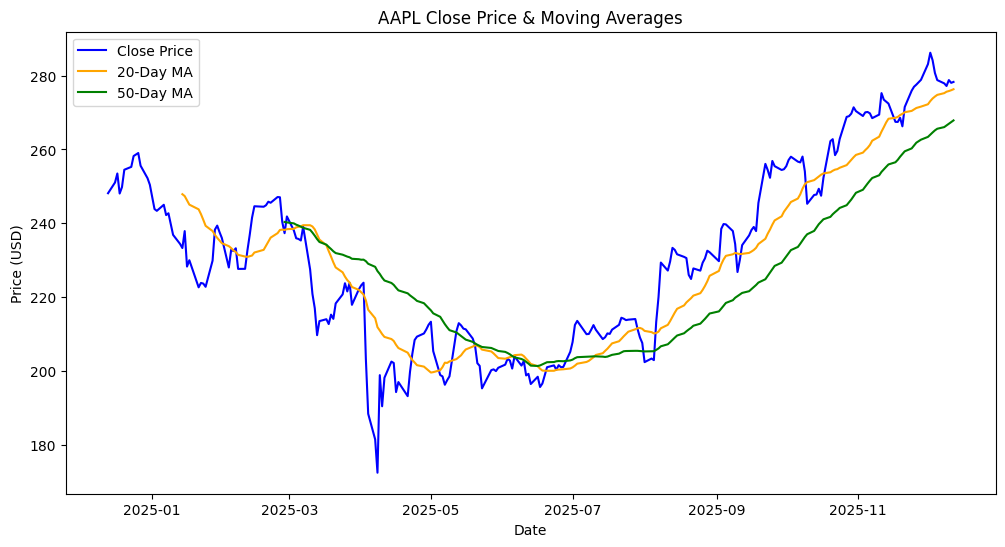

In [6]:
# ==============================
# Cell 6: Calculate and Plot Moving Averages
# ==============================

# Step 7a: Calculate 20-day moving average
# .rolling(window=20) creates a moving window of 20 trading days
# .mean() calculates the average closing price within that window
# This smooths out short-term fluctuations in the stock price
stock_data['MA20'] = stock_data['Close'].rolling(window=20).mean()

# Step 7b: Calculate 50-day moving average
# A longer window gives a medium-term trend perspective
stock_data['MA50'] = stock_data['Close'].rolling(window=50).mean()

# Step 7c: Set up the figure for plotting
plt.figure(figsize=(12,6))

# Step 7d: Plot the original closing price
plt.plot(stock_data.index, stock_data['Close'], label='Close Price', color='blue')

# Step 7e: Plot 20-day moving average
plt.plot(stock_data.index, stock_data['MA20'], label='20-Day MA', color='orange')

# Step 7f: Plot 50-day moving average
plt.plot(stock_data.index, stock_data['MA50'], label='50-Day MA', color='green')

# Step 7g: Add title and axis labels
plt.title(f'{ticker_symbol} Close Price & Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')

# Step 7h: Display legend to differentiate the lines
plt.legend()

# Step 7i: Show the plot
plt.show()


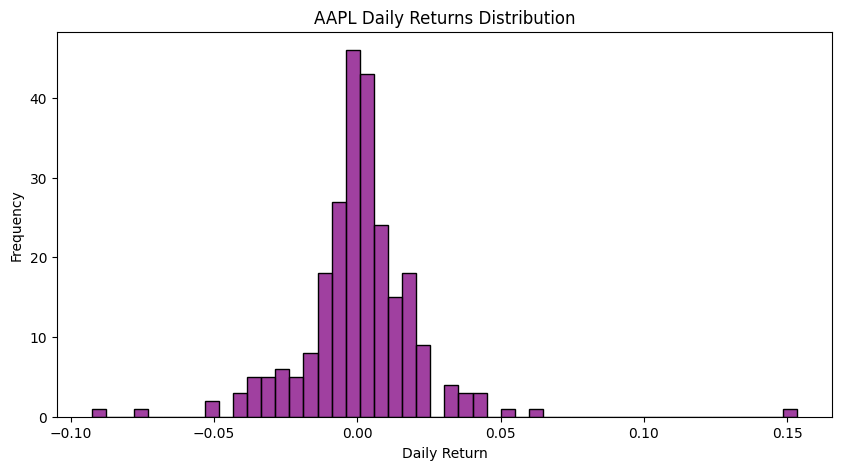

In [7]:
# ==============================
# Cell 7: Calculate and Visualize Daily Returns
# ==============================

# Step 8a: Calculate daily percentage change in closing price
# .pct_change() computes (current_day - previous_day) / previous_day
# This gives the daily return as a decimal (e.g., 0.02 = 2%)
# This helps quantify volatility in the stock
stock_data['Daily_Return'] = stock_data['Close'].pct_change()

# Step 8b: Set up the figure for the histogram
plt.figure(figsize=(10,5))

# Step 8c: Plot histogram of daily returns
# dropna() is used to remove the first NaN generated by pct_change()
# bins=50 creates 50 intervals for the histogram
# color='purple' sets the bar color
sns.histplot(stock_data['Daily_Return'].dropna(), bins=50, color='purple')

# Step 8d: Add title and axis labels
plt.title(f'{ticker_symbol} Daily Returns Distribution')
plt.xlabel('Daily Return')  # X-axis represents percentage change
plt.ylabel('Frequency')     # Y-axis represents how often each return occurred

# Step 8e: Display the histogram
plt.show()
